# Figure 3 Reproduction

This notebook reproduces Figure 3 from the paper, plotting model latencies (preprocessing, UDA update, prediction, and finetuning) from a pre-processed CSV file. By default the values *as published* (`latency_published.csv`, transcribed from the paper's latency table; the raw run is not available) are plotted in the three published panels. Set `LATENCY_SOURCE = "rerun"` to plot the 2026-01 re-measurement instead (adds a MOABB-preprocessing panel). The plot shows performance on both CPU and GPU, with marker size indicating the model's parameter count.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter, FixedLocator
from matplotlib.legend import Legend
import matplotlib.ticker


# --- Helpers ---
def cm2inch(*dims):
    """Converts dimensions from centimeters to inches."""
    inch_per_cm = 2.54
    if isinstance(dims[0], (list, tuple)):
        return tuple(d / inch_per_cm for d in dims[0])
    return tuple(d / inch_per_cm for d in dims)


# --- Configuration ---
LATENCY_SOURCE = "published"  # "published" (paper values) or "rerun" (2026-01 re-measurement)
TARGET_DATASET = "Yang2025"
GLOBAL_FONTSIZE = 7
LEGEND_FONTSIZE = 6.5
PANEL_LABEL_FONTSIZE = 10

param_counts_map = {
    "ShallowConvNet": 121_200,
    "EEGNetv4": 12_700,
    "ATCNet": 114_700,
    "DeepConvNet": 321_500,
}

device_marker_color = {"cpu": "#7f7f7f", "cuda": "#2ca02c"}
model_size_marker_shape = "o"

if LATENCY_SOURCE == "published":
    plots_config = [
        ("tta_update_latency_ms_median", "UDA update latency\n(ms/trial)"),
        ("pred_latency_ms_median", "Prediction latency\n(ms/trial)"),
        ("finetune_step_latency_ms_median", "Finetuning latency\n(ms/finetuning step)"),
    ]
    N_ROWS, N_COLS, FIGSIZE_CM = 1, 3, (9, 8.6)
elif LATENCY_SOURCE == "rerun":
    plots_config = [
        # ("filter_latency_ms_median", "Preprocessing latency\n(ms/trial)"),
        ("moabb_preproc_latency_ms_median", "MOABB preprocessing\n(ms/trial)"),
        ("tta_update_latency_ms_median", "UDA update latency\n(ms/trial)"),
        ("pred_latency_ms_median", "Prediction latency\n(ms/trial)"),
        ("finetune_step_latency_ms_median", "Finetuning latency\n(ms/finetuning step)"),
    ]
    N_ROWS, N_COLS, FIGSIZE_CM = 2, 2, (9, 11)
else:
    raise ValueError(f"unknown LATENCY_SOURCE {LATENCY_SOURCE!r}")

# --- Style Configuration ---
# Using fallback styles directly to ensure reproducibility.
rc_params = {
    "font.size": GLOBAL_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
    "axes.titlesize": GLOBAL_FONTSIZE,
    "axes.labelsize": GLOBAL_FONTSIZE,
    "xtick.labelsize": GLOBAL_FONTSIZE,
    "ytick.labelsize": GLOBAL_FONTSIZE,
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "axes.titleweight": "normal",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

In [2]:
# --- Data Loading and Preparation ---
# Create a directory for the data if it doesn't exist.
data_dir = Path("figure_data")
data_dir.mkdir(exist_ok=True)

if LATENCY_SOURCE == "published":
    COLLATED_CSV_PATH = data_dir / "latency_published.csv"
else:
    COLLATED_CSV_PATH = data_dir / "latency_rerun_2026-01_Yang2025.csv"

if not COLLATED_CSV_PATH.exists():
    raise FileNotFoundError(f"{COLLATED_CSV_PATH} not found (shipped in figure_data/).")


def published_to_long(pub):
    """Reshape latency_published.csv to one row per (dataset, model, device)."""
    metric = {"pred": "pred_latency_ms_median", "uda": "tta_update_latency_ms_median",
              "cft": "finetune_step_latency_ms_median"}
    parts = []
    for device, suffix in [("cpu", "cpu"), ("cuda", "gpu")]:
        part = pub[["dataset", "model", "total_params"]].copy()
        part["device"] = device
        for key, col in metric.items():
            part[col] = pub[f"{key}_ms_{suffix}"]
        parts.append(part)
    return pd.concat(parts, ignore_index=True)


# Load the data
try:
    df_full = pd.read_csv(COLLATED_CSV_PATH)
    if LATENCY_SOURCE == "published":
        df_full = published_to_long(df_full)
    print(f"Successfully loaded data from: {COLLATED_CSV_PATH}")
except (FileNotFoundError, pd.errors.EmptyDataError) as e:
    print(
        f"Error reading {COLLATED_CSV_PATH}: {e}. Please ensure the file exists and is not empty."
    )
    df_full = pd.DataFrame()  # Create empty dataframe to avoid further errors

# Prepare the final dataframe for plotting
if not df_full.empty:
    TARGET_MODELS = ["ShallowConvNet", "EEGNetv4", "ATCNet", "DeepConvNet"]
    df = df_full[
        (df_full["model"].isin(TARGET_MODELS)) & (df_full["dataset"] == TARGET_DATASET)
    ].copy()
    df.loc[:, "param_count"] = df["model"].map(param_counts_map)
    df["param_count"].fillna(df.get("total_params", 10000), inplace=True)
    print(f"Data prepared for plotting. Shape: {df.shape}")
else:
    df = pd.DataFrame()

Successfully loaded data from: figure_data/latency_published.csv
Data prepared for plotting. Shape: (8, 27)


Saved plot to: plots/figure3.pdf


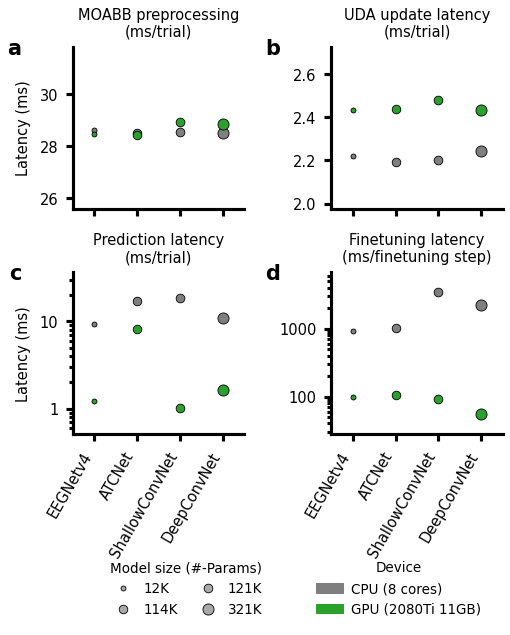

In [4]:
# --- Plotting ---
if not df.empty:
    # Apply the style configuration using a context manager
    with plt.rc_context(rc_params):
        # Create a directory for the plots
        output_plot_dir = Path("plots")
        output_plot_dir.mkdir(exist_ok=True)

        fig, axes = plt.subplots(
            nrows=N_ROWS, ncols=N_COLS, sharey=False, figsize=cm2inch(*FIGSIZE_CM)
        )
        axes = np.atleast_1d(axes).flatten()
        param_marker_scale_factor = 0.050

        for i, (metric_col, y_label_base_title) in enumerate(plots_config):
            ax = axes[i]
            ax.set_title(y_label_base_title, pad=5)
            panel_label = chr(ord("a") + i)
            ax.text(
                -0.3,
                1.05,
                panel_label,
                transform=ax.transAxes,
                fontsize=PANEL_LABEL_FONTSIZE,
                fontweight="bold",
                va="top",
                ha="right",
            )

            if metric_col not in df.columns or df.dropna(subset=[metric_col]).empty:
                ax.text(
                    0.5,
                    0.5,
                    "No Data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                continue

            metric_df_subplot_full = df.dropna(subset=[metric_col])
            unique_models_in_subplot = sorted(metric_df_subplot_full["model"].unique())
            model_param_counts_for_sort = (
                metric_df_subplot_full[["model", "param_count"]]
                .drop_duplicates()
                .set_index("model")["param_count"]
            )
            subplot_model_order = sorted(
                unique_models_in_subplot,
                key=lambda m: model_param_counts_for_sort.get(m, float("inf")),
            )

            ax.set_yscale("log")
            all_data_for_metric = metric_df_subplot_full[metric_col]
            data_min = all_data_for_metric.min()
            data_max = all_data_for_metric.max()
            ax.set_ylim(
                max(data_min * 0.5, 1e-4),
                data_max * 2,
            )

            # Check if data range spans less than one order of magnitude
            data_range_ratio = data_max / max(data_min, 1e-10)
            if data_range_ratio < 10 and LATENCY_SOURCE != "published":
                # Use linear scale for narrow ranges
                ax.set_yscale("linear")
                ax.set_ylim(data_min * 0.9, data_max * 1.1)
            else:
                ax.yaxis.set_major_formatter(
                    FuncFormatter(
                        lambda x, pos: f"{x:.2f}" if x < 1 else f"{int(round(x))}"
                    )
                )
                ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
                ax.yaxis.set_minor_formatter(NullFormatter())
                if LATENCY_SOURCE == "published" and metric_col == "tta_update_latency_ms_median":
                    ax.yaxis.set_major_locator(FixedLocator([1, 5]))  # ticks as in the published panel

            # Add y-label only to left column
            if i % N_COLS == 0:
                ax.set_ylabel("Latency (ms)")

            for model_idx, model_name in enumerate(subplot_model_order):
                model_subplot_data = metric_df_subplot_full[
                    metric_df_subplot_full["model"] == model_name
                ]
                for device in ["cpu", "cuda"]:
                    device_data = model_subplot_data[
                        model_subplot_data["device"] == device
                    ]
                    if not device_data.empty and pd.notna(
                        device_data[metric_col].iloc[0]
                    ):
                        latency_val = device_data[metric_col].iloc[0]
                        params = device_data["param_count"].iloc[0]
                        marker_s = np.sqrt(params) * param_marker_scale_factor
                        ax.scatter(
                            model_idx,
                            latency_val,
                            marker=model_size_marker_shape,
                            color=device_marker_color[device],
                            zorder=3,
                            s=marker_s,
                            edgecolor="black",
                            linewidth=0.4,
                            alpha=1,
                        )

            ax.set_xticks(range(len(subplot_model_order)))
            ax.set_xticklabels(
                subplot_model_order, rotation=60, ha="right", fontsize=GLOBAL_FONTSIZE
            )
            ax.set_xlim(left=-0.5, right=len(subplot_model_order) - 0.5)

            # Ensure y-tick labels are visible
            ax.tick_params(axis="y", which="both", labelleft=True)

        # --- Combined Legend Configuration ---
        # 1. Model Size handles
        legend_param_values = sorted(list(set(param_counts_map.values())))
        param_handles = [
            Line2D(
                [],
                [],
                marker=model_size_marker_shape,
                linestyle="None",
                markersize=np.sqrt(np.sqrt(p) * param_marker_scale_factor),
                color="darkgrey",
                markeredgecolor="black",
                markeredgewidth=0.4,
            )
            for p in legend_param_values
        ]
        param_labels = [f"{int(p / 1000)}K" for p in legend_param_values]

        # 2. Device handles
        device_handles = [
            Rectangle((0, 0), 1, 1, color=c, edgecolor="black", linewidth=0.5)
            for c in device_marker_color.values()
        ]
        device_labels = ["CPU (8 cores)", "GPU (2080Ti 11GB)"]

        # 3. Create and place 'Model Size' legend
        leg_params = Legend(
            fig,
            handles=param_handles,
            labels=param_labels,
            loc="lower center",
            bbox_to_anchor=(0.35, 0.01),
            ncol=2,
            frameon=False,
            title="Model size (#-Params)",
            fontsize=LEGEND_FONTSIZE,
            handletextpad=0.5,
            columnspacing=1.2,
        )
        leg_params.get_title().set_fontsize(GLOBAL_FONTSIZE - 0.5)
        leg_params.get_title().set_fontweight("normal")

        # 4. Create and place 'Device' legend
        leg_device = Legend(
            fig,
            handles=device_handles,
            labels=device_labels,
            loc="lower center",
            bbox_to_anchor=(0.75, 0.01),
            ncol=1,
            frameon=False,
            title="Device",
            fontsize=LEGEND_FONTSIZE,
            handletextpad=0.6,
        )
        leg_device.get_title().set_fontsize(GLOBAL_FONTSIZE - 0.5)
        leg_device.get_title().set_fontweight("normal")

        # 5. Add legends to the figure
        fig.add_artist(leg_params)
        fig.add_artist(leg_device)

        # 6. Show x-axis labels only in the bottom row
        for ax in axes[: N_COLS * (N_ROWS - 1)]:
            ax.set_xticklabels([], rotation=0, ha="center", fontsize=GLOBAL_FONTSIZE)
        for ax in axes[N_COLS * (N_ROWS - 1) :]:
            ax.set_xticklabels(
                ax.get_xticklabels(), rotation=60, ha="right", fontsize=GLOBAL_FONTSIZE
            )

        plt.tight_layout(rect=[0, 0.1, 1, 1])

        # --- Save and Show Figure ---
        output_filename = output_plot_dir / "figure3.pdf"
        plt.savefig(output_filename, bbox_inches="tight")
        plt.savefig(output_filename.with_suffix(".png"), dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {output_filename}")

        plt.show()
else:
    print("DataFrame is empty. Skipping plotting.")